<a href="https://colab.research.google.com/github/ChidiTonio/Explainable-Agentic-AI-Credit-Risk-Nigeria/blob/main/Explainable_Agentic_AI_Credit_Risk_Nigeria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Necessary libraries (run once in Colab)
!pip install xgboost lightgbm shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb






In [2]:
# ==========================================
# 1. Generate Synthetic Nigerian Context Data
# ==========================================
np.random.seed(42)
n_samples = 10000

# Features mimicking alternative credit data in Nigeria
data = {
    'bvn_credit_score': np.random.normal(650, 100, n_samples).clip(300, 900),
    'monthly_ussd_txn_vol': np.random.exponential(50, n_samples), # Mobile money/USSD volume
    'airtime_recharge_avg': np.random.gamma(5, 200, n_samples),   # Airtime spend (income proxy)
    'digital_loan_history': np.random.poisson(2, n_samples),      # Previous loan apps used
    'utility_payment_regularity': np.random.beta(5, 2, n_samples),# 0 to 1 scale
    'age': np.random.normal(35, 10, n_samples).clip(18, 70),
    'informal_income_proxy': np.random.lognormal(10, 1, n_samples) # Naira equivalent
}
df = pd.DataFrame(data)

# Target: Default (1) or Repaid (0). Make it imbalanced (typical in credit risk)
# Higher BVN, higher utility regularity -> lower default risk
default_prob = 1 / (1 + np.exp(0.005 * df['bvn_credit_score'] +
                               2 * df['utility_payment_regularity'] -
                               0.01 * df['airtime_recharge_avg'] -
                               0.5 * df['informal_income_proxy']/10000 +
                               0.2 * df['digital_loan_history'] - 5))
df['default'] = np.random.binomial(1, default_prob)

X = df.drop('default', axis=1)
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# ==========================================
# 2. Train Models
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(scale_pos_weight=9, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(is_unbalance=True, verbose=-1),
    'Proposed Agentic Ensemble': StackingClassifier(
        estimators=[
            ('xgb', xgb.XGBClassifier(scale_pos_weight=9, use_label_encoder=False, eval_metric='logloss')),
            ('lgbm', lgb.LGBMClassifier(is_unbalance=True, verbose=-1)),
            ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
        ],
        final_estimator=LogisticRegression(),
        cv=3
    )
}

trained_models = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        trained_models[name] = (model, X_test_scaled)
    else:
        model.fit(X_train, y_train)
        trained_models[name] = (model, X_test)



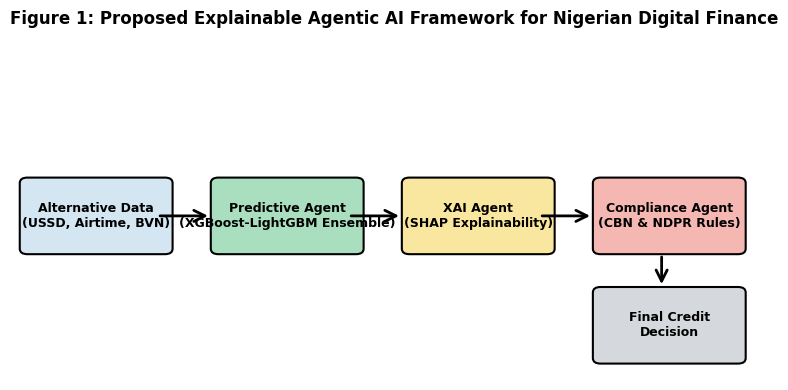

In [9]:
# ==========================================
# FIGURE 1: Multi-Agent Architecture Diagram
# ==========================================
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Define boxes
boxes = [
    (1, 3, "Alternative Data\n(USSD, Airtime, BVN)", '#d4e6f1'),
    (3.5, 3, "Predictive Agent\n(XGBoost-LightGBM Ensemble)", '#a9dfbf'),
    (6, 3, "XAI Agent\n(SHAP Explainability)", '#f9e79f'),
    (8.5, 3, "Compliance Agent\n(CBN & NDPR Rules)", '#f5b7b1'),
    (8.5, 1, "Final Credit\nDecision", '#d5d8dc')
]

for x, y, text, color in boxes:
    box = FancyBboxPatch((x-0.8, y-0.6), 1.8, 1.2, boxstyle="round,pad=0.1",
                         edgecolor='black', facecolor=color, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x+0.1, y, text, ha='center', va='center', fontsize=9, fontweight='bold')

# Draw arrows
arrows = [
    (1.9, 3, 2.6, 3), (4.4, 3, 5.1, 3), (6.9, 3, 7.6, 3), (8.5, 2.3, 8.5, 1.7)
]
for x1, y1, x2, y2 in arrows:
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=20, linewidth=2, color='black')
    ax.add_patch(arrow)

plt.title("Figure 1: Proposed Explainable Agentic AI Framework for Nigerian Digital Finance", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("Fig1_Architecture.png", dpi=300, bbox_inches='tight')
plt.show()

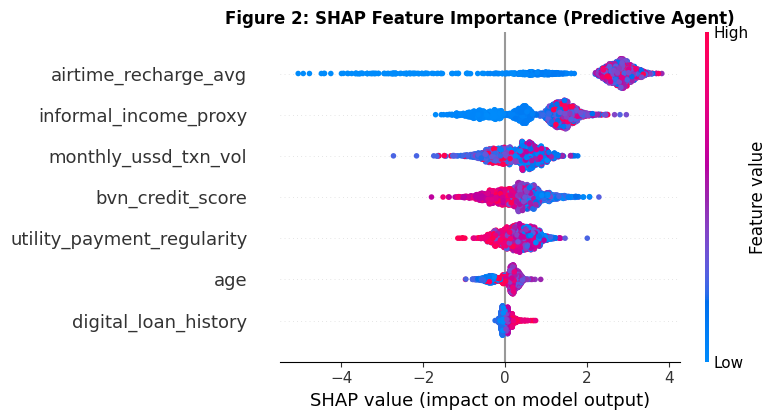

In [5]:
# ==========================================
# FIGURE 2: SHAP Summary Plot (Beeswarm)
# ==========================================
# We use the XGBoost model for SHAP as it's tree-based and fast
xgb_model = trained_models['XGBoost'][0]
X_test_xgb = trained_models['XGBoost'][1]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb)

plt.figure()
shap.summary_plot(shap_values, X_test_xgb, feature_names=X.columns, show=False, max_display=7)
plt.title("Figure 2: SHAP Feature Importance (Predictive Agent)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("Fig2_SHAP_Beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# ==========================================
# 2. Train Models
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(scale_pos_weight=9, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(is_unbalance=True, verbose=-1),
    'Proposed Agentic Ensemble': StackingClassifier(
        estimators=[
            ('xgb', xgb.XGBClassifier(scale_pos_weight=9, use_label_encoder=False, eval_metric='logloss')),
            ('lgbm', lgb.LGBMClassifier(is_unbalance=True, verbose=-1)),
            ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
        ],
        final_estimator=LogisticRegression(),
        cv=3
    )
}

trained_models = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        trained_models[name] = (model, X_test_scaled)
    else:
        model.fit(X_train, y_train)
        trained_models[name] = (model, X_test)

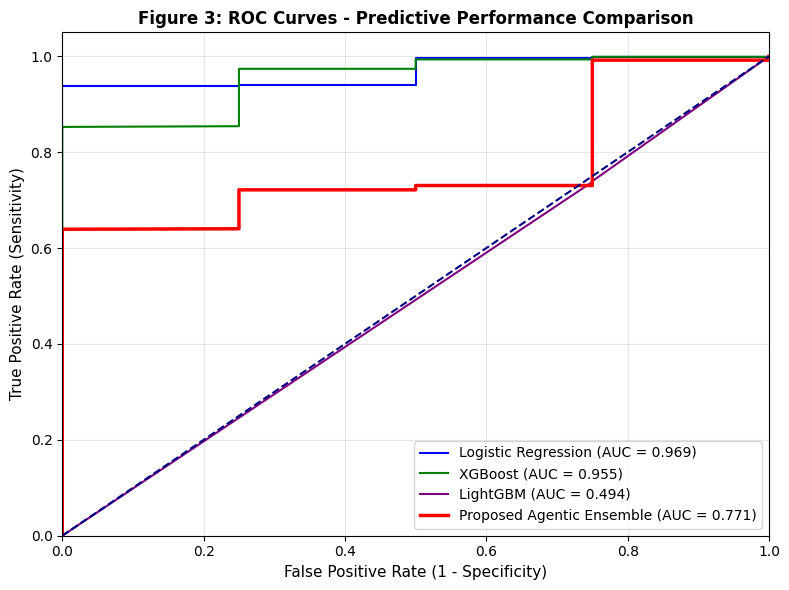

All figures generated and saved successfully!


In [7]:
# ==========================================
# FIGURE 3: ROC Curves Comparison
# ==========================================
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'purple', 'red']

for (name, (model, X_t)), color in zip(trained_models.items(), colors):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_t)[:, 1]
    else:
        y_prob = model.decision_function(X_t)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    lw = 2.5 if name == 'Proposed Agentic Ensemble' else 1.5
    plt.plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Figure 3: ROC Curves - Predictive Performance Comparison', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Fig3_ROC_Curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("All figures generated and saved successfully!")